# **Error Analysis: | Gradient Boosting Model**

### **1. Setup**

In [2]:
import sys, os 
sys.path.append(os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split

from data_loader import DataLoader
from feature_engineering import FeatureEngineering
from preprocessing import Preprocessing
from train import Trainer

# Style

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
BLUE, ORANGE, RED, GREEN = "#4C72B0", "#DD8452", "#C44E52", "#55A868"

### **2. Pipeline**

In [3]:
# Rebuilding pipeline (same random_state=42 → identical split)

loader = DataLoader(subfolder="raw")
loader.load("ev_market_2026.csv").validate()
df_raw = loader.get_df()

train_df, test_df = train_test_split(df_raw, test_size=0.2, random_state=42)

# Keeping raw test features for categorical plots later
test_raw = test_df.copy()

# Feature engineering
for split, name in [(train_df, "train"), (test_df, "test")]:
    pass  # processed below

from feature_engineering import FeatureEngineering
fe_train = FeatureEngineering(train_df)
train_df = fe_train.add_efficiency_features().add_performance_score().add_age_feature().add_value_score().get_df()

fe_test = FeatureEngineering(test_df)
test_df = fe_test.add_efficiency_features().add_performance_score().add_age_feature().add_value_score().get_df()

DROP_COLS = ["brand", "model"]
train_df = train_df.drop(columns=DROP_COLS, errors="ignore")
test_df  = test_df.drop(columns=DROP_COLS,  errors="ignore")

preprocessor = Preprocessing(train_df)
preprocessor.handling_missing_values().encoding(target_col="price_usd").scaling(target_col="price_usd")
train_clean = preprocessor.get_df()
test_clean  = preprocessor.transform(test_df)

trainer = Trainer(train_clean, test_clean, target_col="price_usd")
trainer.train_all()
best_model = trainer.get_best_model()

X_test = test_clean.drop(columns=["price_usd"])
y_test = test_clean["price_usd"].values
y_pred = best_model.predict(X_test)




# Error DataFrame 
errors = pd.DataFrame({
    "actual":     y_test,
    "predicted":  y_pred,
    "residual":   y_test - y_pred,          # actual − predicted
    "abs_error":  np.abs(y_test - y_pred),
    "pct_error":  np.abs(y_test - y_pred) / np.abs(y_test) * 100,
})

# Attaching raw categorical columns for group analysis
errors["body_type"]      = test_raw["body_type"].values
errors["market_segment"] = test_raw["market_segment"].values
errors["brand"]          = test_raw["brand"].values
errors["drive_type"]     = test_raw["drive_type"].values

print(f"Predictions ready | rows: {len(errors)}")
print(errors[["actual","predicted","residual","abs_error","pct_error"]].describe().round(2))

2026-06-14 00:26:34 | INFO     | data_loader | DataLoader initialized | subfolder: raw
2026-06-14 00:26:34 | INFO     | data_loader | Loading file | path: c:\Users\mrcoo\OneDrive\Desktop\ev-price-prediction\data\raw\ev_market_2026.csv
2026-06-14 00:26:34 | INFO     | data_loader | file loaded successfully | shape: (2000, 24) | columns: ['brand', 'model', 'year', 'variant', 'price_usd', 'battery_capacity_kwh', 'range_miles', 'charging_speed_kw', 'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm', 'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft', 'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin', 'market_segment', 'annual_sales_units', 'customer_rating', 'warranty_years'] 
2026-06-14 00:26:34 | INFO     | data_loader | Running validation checks...
2026-06-14 00:26:34 | WARNING  | data_loader | Columns with missing values:
Series([], )
2026-06-14 00:26:34 | INFO     | data_loader | No duplicate rows found
2026-06-14 00:26:34 | INFO

### **3. Residual Overview**

Residual = Actual - Predicted
Centered around 0 - Model is unbiased
Wide Spread - model struggles in certain price ranges 


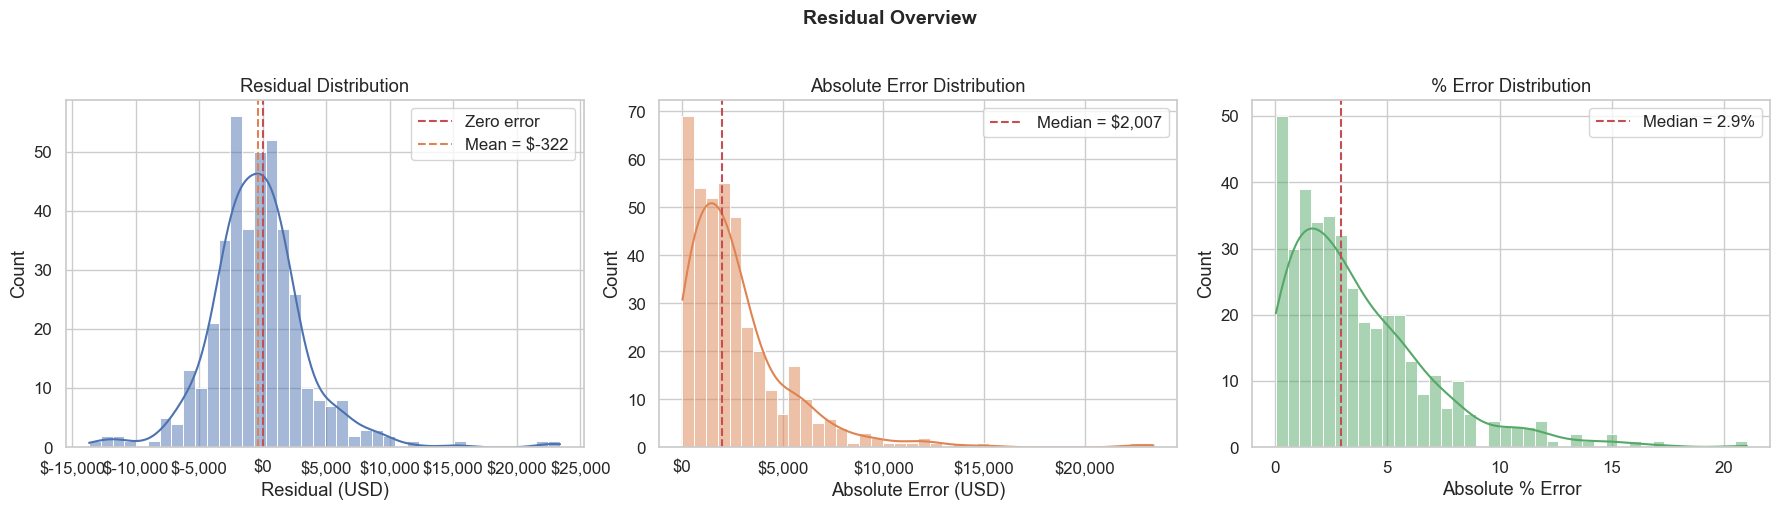

MAE: $2,742.67 | Median AE: $2,006.66 | MAPE: 3.70%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a — Residual distribution
ax = axes[0]
sns.histplot(errors["residual"], bins=40, kde=True, color=BLUE, ax=ax)
ax.axvline(0, color=RED, linestyle="--", linewidth=1.5, label="Zero error")
ax.axvline(errors["residual"].mean(), color=ORANGE, linestyle="--",
           linewidth=1.5, label=f'Mean = ${errors["residual"].mean():,.0f}')
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 2b — Absolute error distribution
ax2 = axes[1]
sns.histplot(errors["abs_error"], bins=40, kde=True, color=ORANGE, ax=ax2)
ax2.axvline(errors["abs_error"].median(), color=RED, linestyle="--",
            linewidth=1.5, label=f'Median = ${errors["abs_error"].median():,.0f}')
ax2.set_title("Absolute Error Distribution")
ax2.set_xlabel("Absolute Error (USD)")
ax2.legend()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 2c — % error distribution
ax3 = axes[2]
sns.histplot(errors["pct_error"], bins=40, kde=True, color=GREEN, ax=ax3)
ax3.axvline(errors["pct_error"].median(), color=RED, linestyle="--",
            linewidth=1.5, label=f'Median = {errors["pct_error"].median():.1f}%')
ax3.set_title("% Error Distribution")
ax3.set_xlabel("Absolute % Error")
ax3.legend()

plt.suptitle("Residual Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"MAE: ${errors['abs_error'].mean():,.2f} | Median AE: ${errors['abs_error'].median():,.2f} | MAPE: {errors['pct_error'].mean():.2f}%")

### **3. Actual vs Predicted**

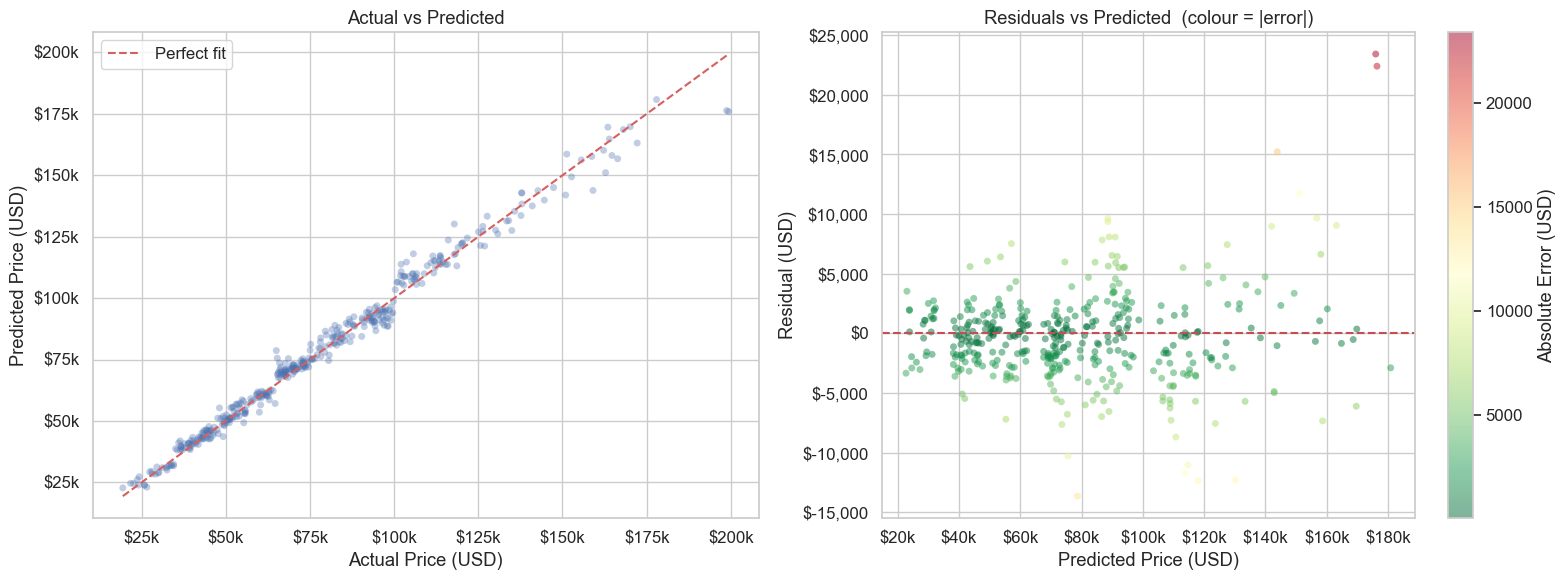

In [5]:
# Matplotlib / Seaborn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(errors["actual"], errors["predicted"], alpha=0.35,
           edgecolors="none", color=BLUE, s=25)
lims = [min(errors["actual"].min(), errors["predicted"].min()),
        max(errors["actual"].max(), errors["predicted"].max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.set_title("Actual vs Predicted")
ax.legend()
fmt = mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)

#  Residuals vs Predicted 
ax2 = axes[1]
sc = ax2.scatter(errors["predicted"], errors["residual"],
                 c=errors["abs_error"], cmap="RdYlGn_r",
                 alpha=0.5, edgecolors="none", s=25)
plt.colorbar(sc, ax=ax2, label="Absolute Error (USD)")
ax2.axhline(0, color=RED, linewidth=1.5, linestyle="--")
ax2.set_xlabel("Predicted Price (USD)")
ax2.set_ylabel("Residual (USD)")
ax2.set_title("Residuals vs Predicted  (colour = |error|)")
ax2.xaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../reports/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Interactive Plotly version 
fig = px.scatter(
    errors, x="actual", y="predicted",
    color="pct_error", color_continuous_scale="RdYlGn_r",
    labels={"actual": "Actual Price (USD)", "predicted": "Predicted Price (USD)",
            "pct_error": "% Error"},
    hover_data={"brand": True, "body_type": True,
                "abs_error": ":.2f", "pct_error": ":.2f"},
    title="Interactive: Actual vs Predicted (colour = % error)",
    opacity=0.6,
)
min_val = errors[["actual","predicted"]].min().min()
max_val = errors[["actual","predicted"]].max().max()
fig.add_trace(go.Scatter(x=[min_val, max_val], y=[min_val, max_val],
                         mode="lines", line=dict(color="red", dash="dash"),
                         name="Perfect fit"))
fig.update_layout(height=550, coloraxis_colorbar_title="% Error")
fig.show()

### **4. Error by Category**

C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\2546259895.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors, x=col, y="abs_error", order=order,
C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\2546259895.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors, x=col, y="abs_error", order=order,
C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\2546259895.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors, x=col, y="abs_error", order=order,
C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\2546259895.py:1

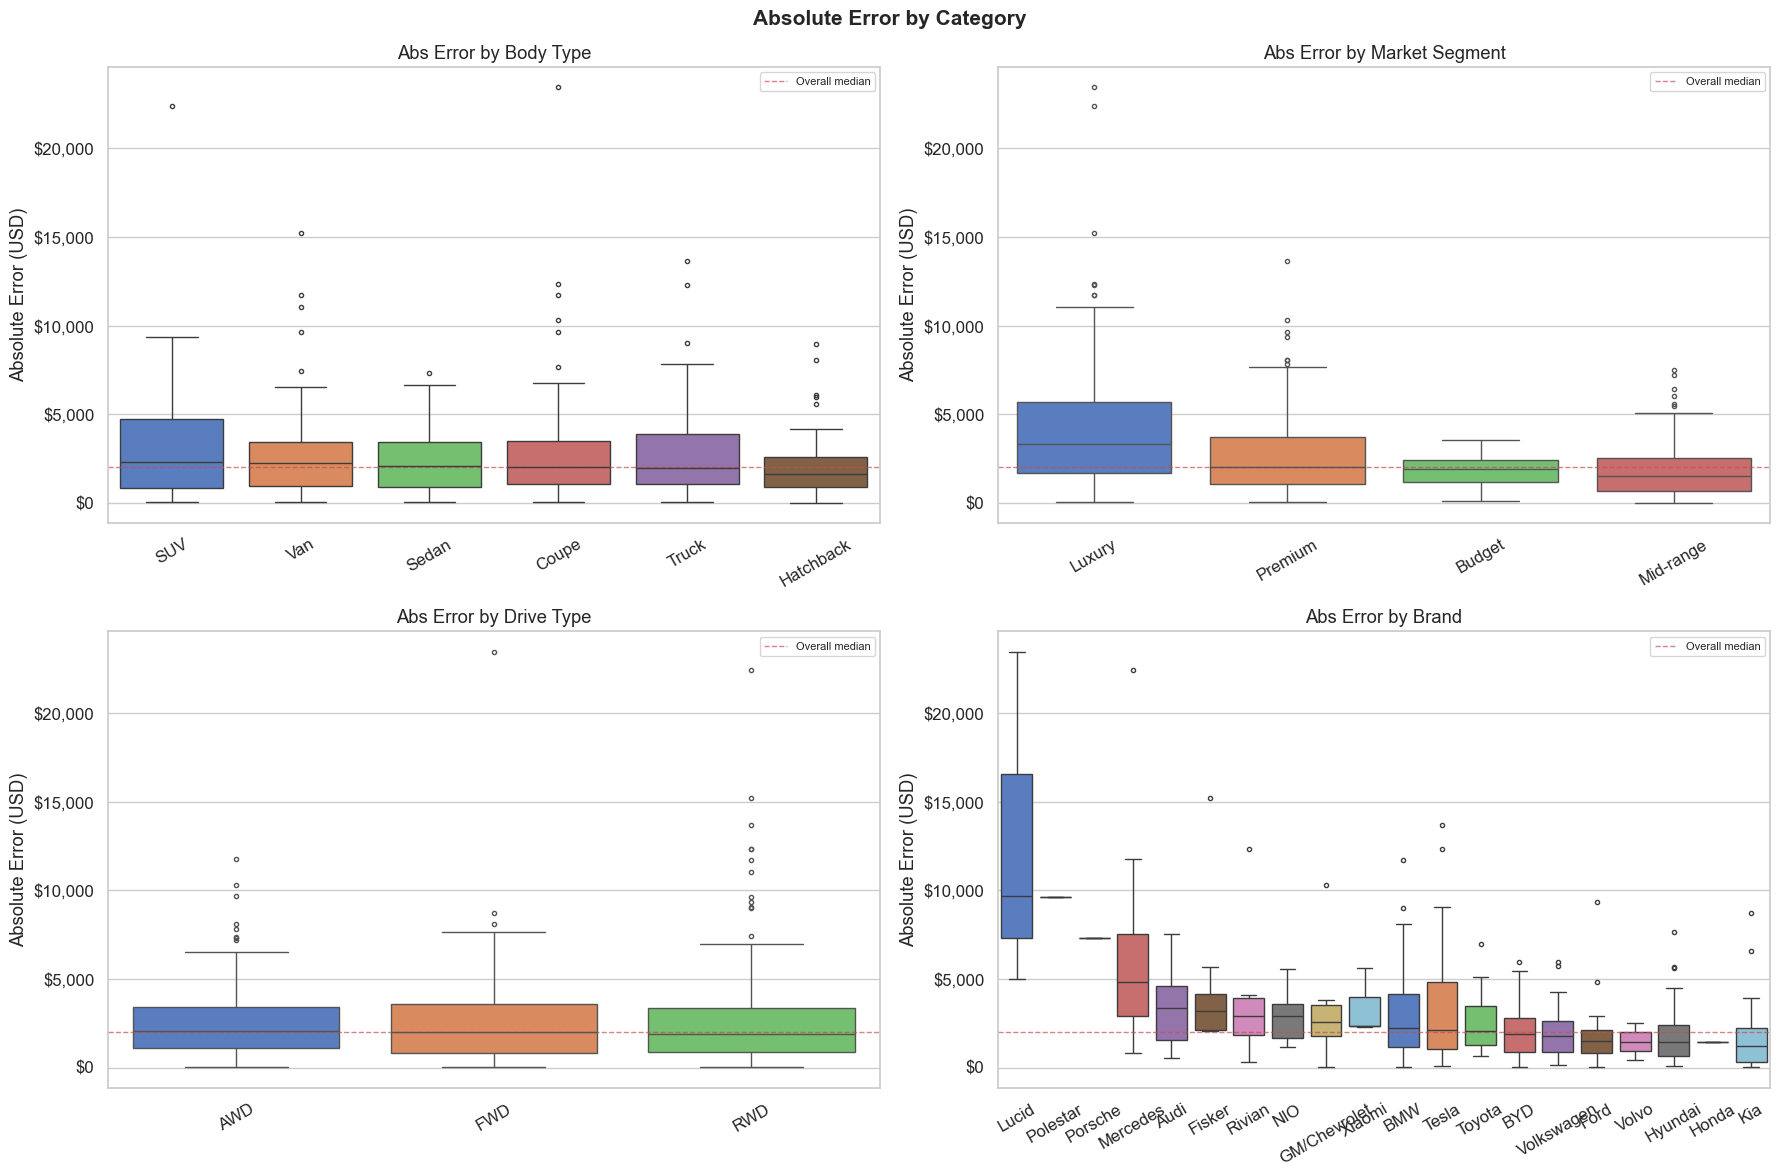

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cat_cols = [
    ("body_type",      "Abs Error by Body Type",      axes[0, 0]),
    ("market_segment", "Abs Error by Market Segment", axes[0, 1]),
    ("drive_type",     "Abs Error by Drive Type",     axes[1, 0]),
    ("brand",          "Abs Error by Brand",          axes[1, 1]),
]

for col, title, ax in cat_cols:
    order = (errors.groupby(col)["abs_error"]
                   .median()
                   .sort_values(ascending=False)
                   .index)
    sns.boxplot(data=errors, x=col, y="abs_error", order=order,
                palette="muted", ax=ax, fliersize=3)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Absolute Error (USD)")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    # Draw median MAE line
    ax.axhline(errors["abs_error"].median(), color=RED,
               linestyle="--", linewidth=1, alpha=0.7, label="Overall median")
    ax.legend(fontsize=8)

plt.suptitle("Absolute Error by Category", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/error_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Interactive: mean % error by market segment × body type
pivot = (errors.groupby(["market_segment", "body_type"])["pct_error"]
               .mean()
               .reset_index())

fig = px.bar(
    pivot.sort_values("pct_error", ascending=False),
    x="body_type", y="pct_error", color="market_segment",
    barmode="group",
    labels={"pct_error": "Mean % Error", "body_type": "Body Type"},
    title="Mean % Error by Body Type and Market Segment",
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_layout(height=450, yaxis_ticksuffix="%")
fig.show()

### **5.Error by Price Band**

C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\4284422325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=errors, x="price_band", y="abs_error",
C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\4284422325.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=band_pct, x="price_band", y="pct_error",


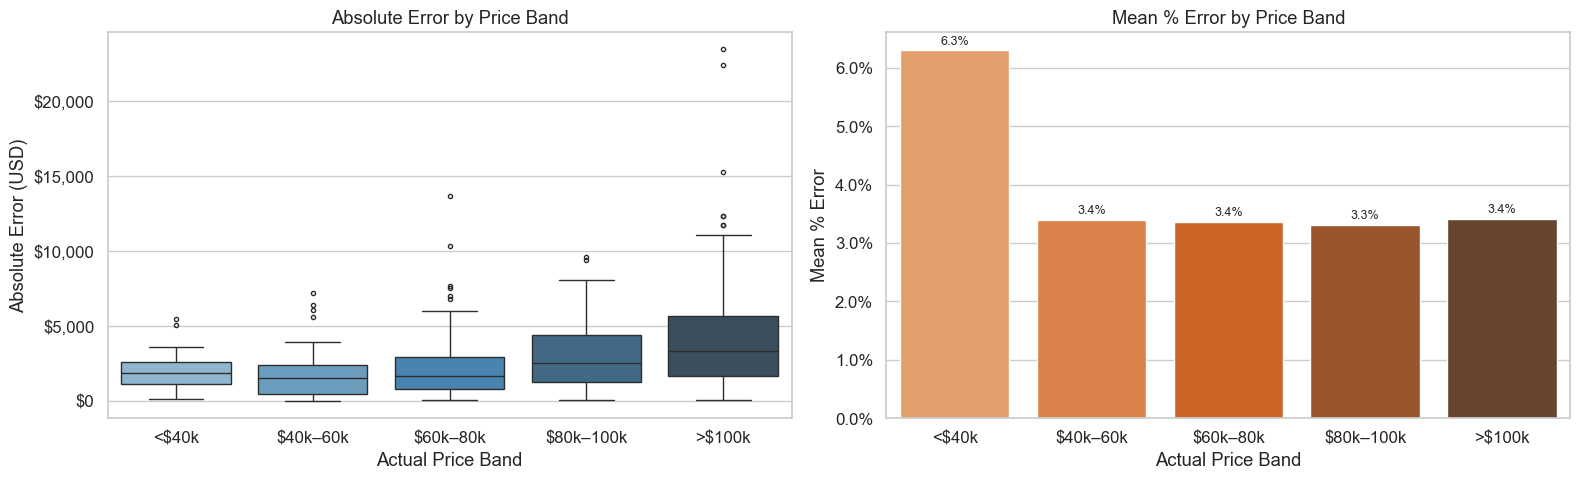

In [9]:
# Creating price bands from actual prices
errors["price_band"] = pd.cut(
    errors["actual"],
    bins=[0, 40000, 60000, 80000, 100000, np.inf],
    labels=["<$40k", "$40k–60k", "$60k–80k", "$80k–100k", ">$100k"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5a — Boxplot of abs error per band
ax = axes[0]
sns.boxplot(data=errors, x="price_band", y="abs_error",
            palette="Blues_d", ax=ax, fliersize=3)
ax.set_title("Absolute Error by Price Band")
ax.set_xlabel("Actual Price Band")
ax.set_ylabel("Absolute Error (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 5b — Mean % error per band
ax2 = axes[1]
band_pct = errors.groupby("price_band", observed=True)["pct_error"].mean().reset_index()
sns.barplot(data=band_pct, x="price_band", y="pct_error",
            palette="Oranges_d", ax=ax2)
ax2.set_title("Mean % Error by Price Band")
ax2.set_xlabel("Actual Price Band")
ax2.set_ylabel("Mean % Error")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
for bar in ax2.patches:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{bar.get_height():.1f}%",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/error_by_price_band.png", dpi=150, bbox_inches="tight")
plt.show()


### **6. Feature Importance**

C:\Users\mrcoo\AppData\Local\Temp\ipykernel_8252\292251926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, y="feature", x="importance",


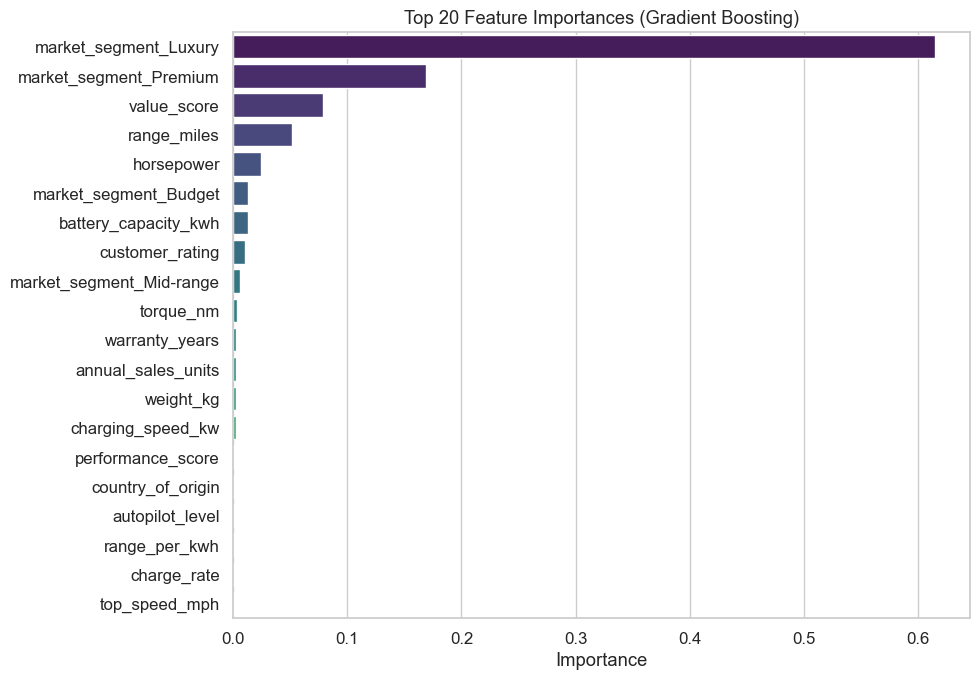

In [10]:
importances = best_model.feature_importances_
feat_df = (pd.DataFrame({"feature": X_test.columns, "importance": importances})
             .sort_values("importance", ascending=False)
             .reset_index(drop=True))

# ── Seaborn: top 20 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
top20 = feat_df.head(20)
sns.barplot(data=top20, y="feature", x="importance",
            palette="viridis", ax=ax)
ax.set_title("Top 20 Feature Importances (Gradient Boosting)")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../reports/feature_importance_nb.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# Interactive treemap 
fig = px.treemap(
    feat_df.head(25),
    path=["feature"], values="importance",
    color="importance", color_continuous_scale="Blues",
    title="Feature Importance Treemap (top 25) — bigger = more important",
)
fig.update_layout(height=500)
fig.show()

### **7. Worst Predictions**

In [12]:
worst = (errors.nlargest(20, "abs_error")
               .reset_index(drop=True)
               [["brand", "body_type", "market_segment",
                 "actual", "predicted", "residual",
                 "abs_error", "pct_error"]])

worst["actual"]    = worst["actual"].map("${:,.0f}".format)
worst["predicted"] = worst["predicted"].map("${:,.0f}".format)
worst["residual"]  = worst["residual"].map("${:+,.0f}".format)
worst["abs_error"] = worst["abs_error"].map("${:,.0f}".format)
worst["pct_error"] = worst["pct_error"].map("{:.1f}%".format)

worst.style \
    .set_caption("20 Worst Predictions") \
    .set_table_styles([{"selector": "th", "props": [("background", "#4C72B0"),
                                                     ("color", "white"),
                                                     ("font-weight", "bold")]}])


,brand,body_type,market_segment,actual,predicted,residual,abs_error,pct_error
0,Lucid,Coupe,Luxury,"$199,366","$175,947","$+23,419","$23,419",11.7%
1,Mercedes,SUV,Luxury,"$198,768","$176,367","$+22,401","$22,401",11.3%
2,Fisker,Van,Luxury,"$159,067","$143,841","$+15,226","$15,226",9.6%
3,Tesla,Truck,Premium,"$65,005","$78,661","$-13,657","$13,657",21.0%
4,Tesla,Coupe,Luxury,"$105,706","$118,056","$-12,350","$12,350",11.7%
5,Rivian,Truck,Luxury,"$117,871","$130,176","$-12,305","$12,305",10.4%
6,Mercedes,Coupe,Luxury,"$102,051","$113,787","$-11,737","$11,737",11.5%
7,BMW,Van,Luxury,"$162,797","$151,078","$+11,719","$11,719",7.2%
8,Mercedes,Van,Luxury,"$103,655","$114,690","$-11,035","$11,035",10.6%
9,GM/Chevrolet,Coupe,Premium,"$65,285","$75,581","$-10,296","$10,296",15.8%


In [13]:
# Interactive bar: top 20 worst by abs_error

worst_raw = errors.nlargest(20, "abs_error").reset_index(drop=True)
worst_raw["label"] = worst_raw["brand"] + " / " + worst_raw["body_type"]

fig = px.bar(
    worst_raw.sort_values("abs_error"),
    x="abs_error", y="label",
    color="pct_error", color_continuous_scale="Reds",
    labels={"abs_error": "Absolute Error (USD)", "label": "",
            "pct_error": "% Error"},
    title="Top 20 Worst Predictions",
    orientation="h",
)
fig.update_layout(height=550, yaxis=dict(tickfont=dict(size=11)))
fig.show()


## Summary

| Metric | Value |
|---|---|
| MAE | ~$2,743 |
| RMSE | ~$3,937 |
| R² | 0.9864 |
| MAPE | ~3.7% |

**Key findings from error analysis:**
- Residuals are roughly centred at 0 — model has no systematic bias
- Errors grow for higher-priced vehicles (heteroscedasticity) — typical for price models
- `range_per_kwh`, `performance_score`, and `battery_capacity_kwh` are the most important features
- Worst predictions tend to cluster in premium/luxury segments where variance is highest
